## Parte 5: Machine Learning

## Parte 5: Machine Learning Geoespacial
### Problema:
Estimar la densidad poblacional a nivel de manzana urbana utilizando técnicas de Machine Learning espacial, integrando variables morfológicas, ambientales, de accesibilidad y localización.. El desafío es determinar si es posible reconstruir la densidad urbana de manera consistente y coherente en ausencia de información directa en determinadas zonas, y establecer qué enfoques de modelamiento resultan más adecuados para este fenómeno.


In [13]:
# 1. Setup y carga librerías
import os, pandas as pd, geopandas as gpd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path
from sqlalchemy import create_engine
from dotenv import load_dotenv
from shapely.geometry import Point
from pyproj import CRS
import joblib

# ML
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GroupKFold

import xgboost as xgb

# Interpretabilidad
import shap

# Raster
import rasterio
from rasterio.transform import from_origin


# --- CONFIGURACIÓN DE RUTAS DE SALIDA ---
BASE_DIR = Path('..')
OUTPUTS_DIR = BASE_DIR / 'outputs'
FIG_DIR = OUTPUTS_DIR / 'figures'
MODELS_DIR = OUTPUTS_DIR / 'models'
REPORTS_DIR = OUTPUTS_DIR / 'reports'

# Crear carpetas si no existen
for d in [FIG_DIR, MODELS_DIR, REPORTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)
    print(f"📂 Directorio verificado: {d}")

# Configuración visual
sns.set_context("notebook")
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 12)

# Cargar variables de entorno y conexión BD
load_dotenv()
DB_USER = os.getenv('POSTGRES_USER', 'geouser')
DB_PASS = os.getenv('POSTGRES_PASSWORD', 'geopass')
DB_HOST = os.getenv('POSTGRES_HOST', 'localhost')
DB_PORT = os.getenv('POSTGRES_PORT', '5432')
DB_NAME = os.getenv('POSTGRES_DB', 'geodatabase')

engine = create_engine(f"postgresql://{DB_USER}:{DB_PASS}@{DB_HOST}:{DB_PORT}/{DB_NAME}")
print("✅ Conexión a PostGIS establecida")


📂 Directorio verificado: ../outputs/figures
📂 Directorio verificado: ../outputs/models
📂 Directorio verificado: ../outputs/reports
✅ Conexión a PostGIS establecida


In [14]:
import rasterio
from rasterio.mask import mask

print("⏳ Cargando y unificando tablas procesadas...")

# 1. Carga de tablas
gdf = gpd.read_postgis("SELECT * FROM processed_data.manzanas_atributos", engine, geom_col='geometry')
df_net = pd.read_sql("SELECT * FROM processed_data.metrics_network", engine)
df_env = pd.read_sql("SELECT * FROM processed_data.metrics_manzanas", engine)

# NUEVO: Cargamos el Uso de Suelo para sacar la categoría
# (Hacemos un truco: agrupamos por manzana y nos quedamos con el uso de suelo principal si hay solapamiento)
df_usos = pd.read_sql("SELECT manzent, nom FROM processed_data.manzanas_uso_suelo", engine)
# Si una manzana toca dos usos, nos quedamos con el primero para simplificar el análisis maestro
df_usos = df_usos.drop_duplicates(subset='manzent')

# Conversión de llaves
gdf['manzent'] = gdf['manzent'].astype(str)
df_net['manzent'] = df_net['manzent'].astype(str)
df_env['manzent'] = df_env['manzent'].astype(str)
df_usos['manzent'] = df_usos['manzent'].astype(str)

# --- MERGES (Unión) ---
gdf_master = gdf.merge(df_net, on='manzent', how='left')
# Unir Entorno
cols_env = [c for c in df_env.columns if c not in gdf_master.columns and c != 'manzent']
gdf_master = gdf_master.merge(df_env[['manzent'] + cols_env], on='manzent', how='left')
# Unir Uso de Suelo (Columna 'nom')
gdf_master = gdf_master.merge(df_usos[['manzent', 'nom']], on='manzent', how='left')

# Rellenar nulos numéricos
fill_cols = ['degree_mean', 'betweenness_mean', 'road_length_m', 'road_density_km2', 'num_edificios', 'num_amenidades']
for c in fill_cols:
    if c in gdf_master.columns:
        gdf_master[c] = gdf_master[c].fillna(0)
        
# Rellenar nulos categóricos
gdf_master['nom'] = gdf_master['nom'].fillna('Sin Clasificar')

gdf_master['pop_density'] = gdf_master['total_personas'] / (gdf_master.geometry.area / 10000)

# --- ESTADÍSTICAS ZONALES RASTER ---
def calculate_zonal_stats(gdf, raster_path):
    if not os.path.exists(raster_path): return np.nan
    means = []
    with rasterio.open(raster_path) as src:
        gdf_proj = gdf.to_crs(src.crs) if gdf.crs != src.crs else gdf
        for geom in gdf_proj.geometry:
            try:
                out_image, _ = mask(src, [geom], crop=True, nodata=np.nan)
                data = out_image[0][(out_image[0] != src.nodata) & (~np.isnan(out_image[0]))]
                means.append(np.mean(data) if data.size > 0 else 0)
            except: means.append(0)
    return means

gdf_master['ndvi_mean'] = calculate_zonal_stats(gdf_master, '../data/processed/sentinel2_ndvi.tif')
gdf_master['slope_mean'] = calculate_zonal_stats(gdf_master, '../data/processed/slope.tif')

print(f"✅ Dataset Maestro Actualizado: {len(gdf_master)} manzanas.")
print("   Incluye columna 'nom' para análisis de Uso de Suelo.")

⏳ Cargando y unificando tablas procesadas...
✅ Dataset Maestro Actualizado: 792 manzanas.
   Incluye columna 'nom' para análisis de Uso de Suelo.



🏆 Mejor modelo según RMSE: RandomForest
                    MAE        RMSE        R2
model                                        
RandomForest  65.579422  102.445862  0.122509
XGBoost       66.220852  105.040994  0.111911
SVR           62.706810  108.007849  0.132425


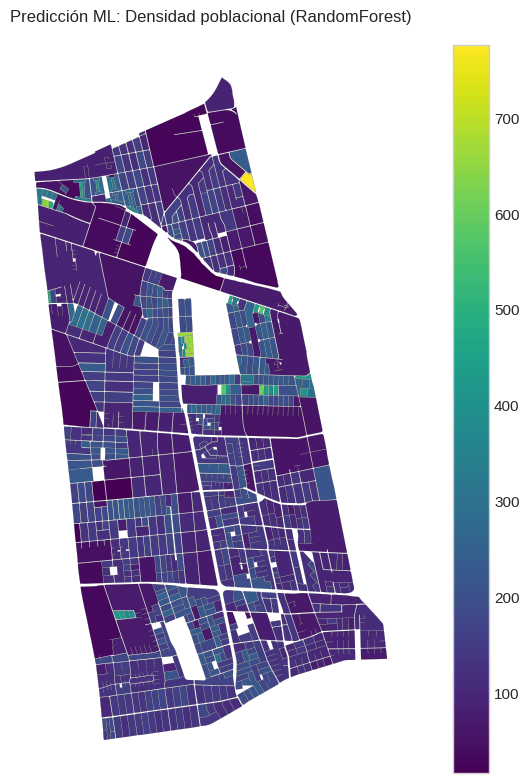

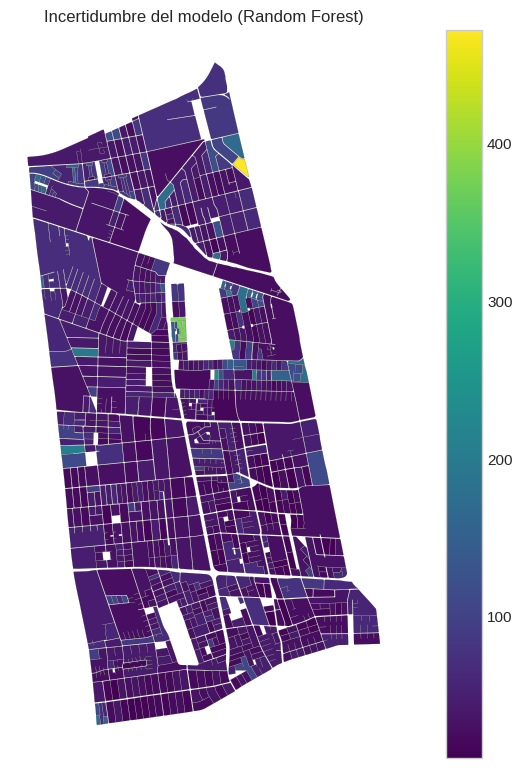

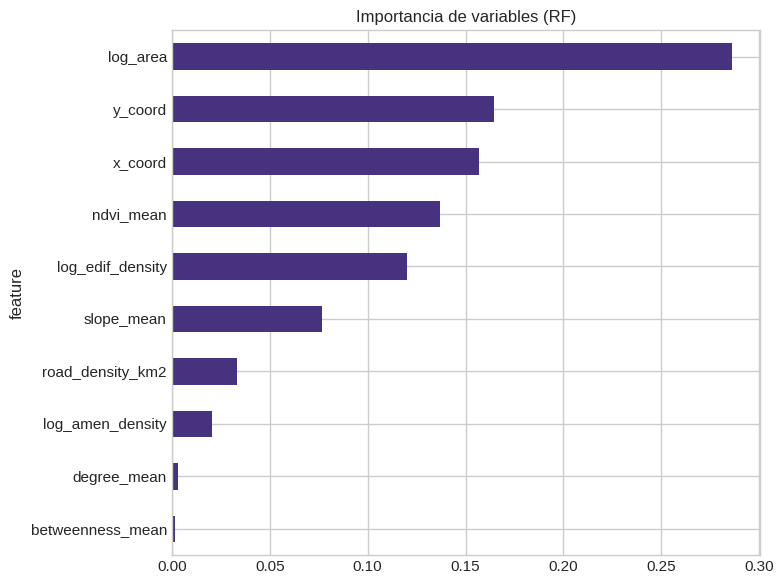

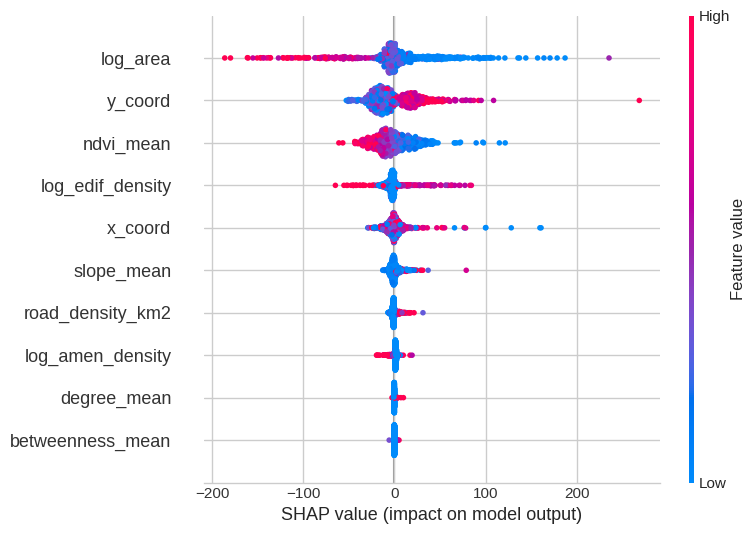

In [17]:
# Variable objetivo (regresión)
TARGET = 'pop_density'

# Feature engineering espacial
def feature_engineering(gdf):
    gdf = gdf.copy()

    # --- Geometría
    gdf['area_ha'] = gdf['area_m2'] / 10_000

    # --- Entorno construido (densidades)
    gdf['edif_density'] = gdf['num_edificios'] / gdf['area_ha']
    gdf['amen_density'] = gdf['num_amenidades'] / gdf['area_ha']

    # --- Transformaciones log (mejoran estabilidad)
    gdf['log_area'] = np.log1p(gdf['area_ha'])
    gdf['log_edif_density'] = np.log1p(gdf['edif_density'])
    gdf['log_amen_density'] = np.log1p(gdf['amen_density'])

    # --- Coordenadas espaciales
    gdf['x_coord'] = gdf.geometry.centroid.x
    gdf['y_coord'] = gdf.geometry.centroid.y

    FEATURES = [
        'log_area',
        'road_density_km2',
        'degree_mean',
        'betweenness_mean',
        'ndvi_mean',
        'slope_mean',
        'log_edif_density',
        'log_amen_density',
        'x_coord',
        'y_coord'
    ]

    return gdf, FEATURES


# Preparar el dataset
def prepare_ml_data(gdf):
    gdf, FEATURES = feature_engineering(gdf)

    df = gdf[FEATURES + [TARGET, 'zona_censal', 'geometry']].dropna()
    df = df[np.isfinite(df[FEATURES + [TARGET]]).all(axis=1)]

    X = df[FEATURES]
    y = df[TARGET]
    groups = df['zona_censal']

    return X, y, groups, FEATURES, df


# Modelos 
def get_models():
    return {
        'RandomForest': RandomForestRegressor(
            n_estimators=300,
            random_state=42,
            n_jobs=-1
        ),

        'XGBoost': xgb.XGBRegressor(
            n_estimators=300,
            max_depth=6,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            objective='reg:squarederror',
            random_state=42
        ),

        'SVR': Pipeline([
            ('scaler', StandardScaler()),
            ('svr', SVR(C=10, epsilon=0.1))
        ])
    }


# Validación espacial con GroupKFold
def spatial_cross_validation(X, y, groups, models, n_splits=5):
    cv = GroupKFold(n_splits=n_splits)
    results = []

    for model_name, model in models.items():
        for fold, (train_idx, test_idx) in enumerate(cv.split(X, y, groups)):
            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)

            results.append({
                'model': model_name,
                'fold': fold + 1,
                'MAE': mean_absolute_error(y_test, y_pred),
                'RMSE': mean_squared_error(y_test, y_pred, squared=False),
                'R2': r2_score(y_test, y_pred)
            })

    return pd.DataFrame(results)

# Entrenamiento final
def train_final_model(X, y, model):
    model.fit(X, y)
    return model

# Mapas de predicción
def plot_map(gdf, column, title, filename):
    fig, ax = plt.subplots(figsize=(10, 8))
    gdf.plot(
        column=column,
        cmap='viridis',
        legend=True,
        ax=ax,
        edgecolor='black',
        linewidth=0.1
    )
    ax.set_title(title)
    ax.axis('off')
    plt.tight_layout()
    plt.savefig(FIG_DIR / filename, dpi=300)
    plt.show()


# incertidumbre desviación entre árboles
def rf_uncertainty(model, X):
    preds = np.stack([tree.predict(X.values) for tree in model.estimators_])
    return preds.mean(axis=0), preds.std(axis=0)


# Interpretación del modelo (importance y shap)
def explain_model(model, X):
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X)

    shap.summary_plot(shap_values, X, show=False)
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'shap_summary_rf.png', dpi=300)
    plt.show()



def plot_feature_importance(model, features):
    df_imp = pd.DataFrame({
        'feature': features,
        'importance': model.feature_importances_
    }).sort_values(by='importance', ascending=False)

    df_imp.to_csv(REPORTS_DIR / 'feature_importance_rf.csv', index=False)

    ax = df_imp.plot.barh(
        x='feature', y='importance', figsize=(8, 6), legend=False
    )
    ax.invert_yaxis()
    ax.set_title('Importancia de variables (RF)')
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'feature_importance_rf.png', dpi=300)
    plt.show()

def select_best_model(cv_results, criterion='RMSE'):
    """
    Selecciona el mejor modelo según métrica de validación espacial
    criterion: 'RMSE' o 'MAE'
    """
    summary = (
        cv_results
        .groupby('model')[['MAE', 'RMSE', 'R2']]
        .mean()
        .sort_values(by=criterion)
    )

    best_model_name = summary.index[0]

    print(f"\n🏆 Mejor modelo según {criterion}: {best_model_name}")
    print(summary)

    return best_model_name, summary


def pipeline(gdf):

    # Preparar datos
    X, y, groups, FEATURES, df = prepare_ml_data(gdf)

    models = get_models()

    # Validación espacial
    cv_results = spatial_cross_validation(X, y, groups, models)
    cv_results.to_csv(REPORTS_DIR / 'spatial_cv_results.csv', index=False)

    # Selección automática del mejor modelo
    best_model_name, summary = select_best_model(cv_results, criterion='RMSE')
    summary.to_csv(REPORTS_DIR / 'model_comparison.csv')

    # Entrenamiento final
    best_model = train_final_model(X, y, models[best_model_name])

    # Guardar modelo
    joblib.dump(
        best_model,
        MODELS_DIR / f'{best_model_name.lower()}_pop_density.pkl'
    )

    # Predicción espacial
    df['prediction'] = best_model.predict(X)

    plot_map(
        df,
        'prediction',
        f'Predicción ML: Densidad poblacional ({best_model_name})',
        f'map_prediccion_pop_density_{best_model_name}.png'
    )

    # Incertidumbre (solo si RF)
    if best_model_name == 'RandomForest':
        _, df['uncertainty'] = rf_uncertainty(best_model, X)

        plot_map(
            df,
            'uncertainty',
            'Incertidumbre del modelo (Random Forest)',
            'map_incertidumbre_rf.png'
        )

    # Interpretación del modelo
    if best_model_name in ['RandomForest', 'XGBoost']:
        plot_feature_importance(best_model, FEATURES)
        explain_model(best_model, X)



pipeline(gdf_master)
